In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib as mpl

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 14 # Axis labels
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick labels
plt.rcParams['font.size'] = 14  # General font size
FONT = 12

code_to_state = {33: 'RJ', 32: 'ES', 41: 'PR', 23: 'CE', 21: 'MA',
 31: 'MG', 42: 'SC', 26: 'PE', 25: 'PB', 24: 'RN', 22: 'PI', 27: 'AL',
 28: 'SE', 35: 'SP', 43: 'RS', 15: 'PA', 16: 'AP', 14: 'RR',  11: 'RO',
 13: 'AM', 12: 'AC', 51: 'MT', 50: 'MS', 52: 'GO', 17: 'TO', 53: 'DF',
 29: 'BA'}

regioes = {
    'Norte': ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO'],
    'Nordeste': ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'Centro-Oeste': ['DF', 'GO', 'MT', 'MS'],
    'Sudeste': ['ES', 'MG', 'RJ', 'SP'],
    'Sul': ['PR', 'RS', 'SC']
}

estado_para_regiao = {est: reg for reg, estados in regioes.items() for est in estados}


In [2]:
challenge = 'dengue_state'

df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [3]:
len(df_preds.model.unique())

21

In [4]:
df_preds.isnull().sum()

date          0
lower_95      0
lower_90      0
lower_80      0
lower_50      0
pred          0
upper_50      0
upper_80      0
upper_90      0
upper_95      0
adm_1         0
id            0
validation    0
wis           0
model         0
dtype: int64

Comparison of the Models' WIS Against the Baseline:

In [5]:
model_baseline = '3rd_imdc_procc_bb_model'

df_agg_wis = df_preds.groupby(['model', 'adm_1', 'validation'])[['wis']].mean().reset_index()

df_baseline = df_agg_wis[df_agg_wis['model'] == model_baseline].copy()
df_modelos = df_agg_wis[df_agg_wis['model'] != model_baseline].copy()

# Renomear a coluna wis do baseline para evitar conflito no merge
df_baseline = df_baseline.rename(columns={'wis': 'baseline_wis'})

# 2. Trazer o valor do baseline para a linha de cada modelo correspondente
# Alinha por Estado (adm_1) e pelo Conjunto de Validação (validation)
df_comparacao = pd.merge(
    df_modelos, 
    df_baseline[['adm_1', 'validation', 'baseline_wis']], 
    on=['adm_1', 'validation'], 
    how='left'
)

# 3. Criar uma coluna booleana indicando se o modelo ganhou do baseline (wis menor)
df_comparacao['ganhou_do_baseline'] = df_comparacao['wis'] <= df_comparacao['baseline_wis']

# 4. Agrupar por Modelo e Estado, somando quantas validações ele ganhou
resultado_agrupado = df_comparacao.groupby(['model', 'adm_1'])['ganhou_do_baseline'].sum().reset_index()

# 5. Filtrar apenas os modelos que ganharam em pelo menos 3 dos 4 conjuntos
modelos_selecionados_3 = resultado_agrupado.loc[resultado_agrupado['ganhou_do_baseline'] >= 3]
modelos_selecionados_2 = resultado_agrupado.loc[resultado_agrupado['ganhou_do_baseline'] == 2]
modelos_selecionados_1 = resultado_agrupado.loc[resultado_agrupado['ganhou_do_baseline'] == 1]
modelos_selecionados_0 = resultado_agrupado.loc[resultado_agrupado['ganhou_do_baseline'] == 0]

In [6]:
modelos_selecionados_0

,model,adm_1,ganhou_do_baseline
4,3rd_imdc_bsc_ghr,15,0
8,3rd_imdc_bsc_ghr,22,0
24,3rd_imdc_bsc_ghr,52,0
27,3rd_imdc_ceri_returnoftheforecast,12,0
29,3rd_imdc_ceri_returnoftheforecast,14,0
...,...,...,...
521,DS-OKSTATE-2026,43,0
522,DS-OKSTATE-2026,50,0
523,DS-OKSTATE-2026,51,0
524,DS-OKSTATE-2026,52,0


In [7]:
resultado_agrupado

,model,adm_1,ganhou_do_baseline
0,3rd_imdc_bsc_ghr,11,1
1,3rd_imdc_bsc_ghr,12,2
2,3rd_imdc_bsc_ghr,13,2
3,3rd_imdc_bsc_ghr,14,1
4,3rd_imdc_bsc_ghr,15,0
...,...,...,...
521,DS-OKSTATE-2026,43,0
522,DS-OKSTATE-2026,50,0
523,DS-OKSTATE-2026,51,0
524,DS-OKSTATE-2026,52,0


In [8]:
model = '3rd_imdc_bsc_ghr'

df_s_model = resultado_agrupado.loc[resultado_agrupado.model == model]
df_s_model['adm_1'] = df_s_model['adm_1'].replace(code_to_state)

# Cria a coluna de região e ordena
df_s_model['regiao'] = df_s_model['adm_1'].map(estado_para_regiao)

df_s_model = df_s_model.sort_values(by=['regiao', 'adm_1'])

df_s_model.head()

,model,adm_1,ganhou_do_baseline,regiao
25,3rd_imdc_bsc_ghr,DF,2,Centro-Oeste
24,3rd_imdc_bsc_ghr,GO,0,Centro-Oeste
22,3rd_imdc_bsc_ghr,MS,3,Centro-Oeste
23,3rd_imdc_bsc_ghr,MT,3,Centro-Oeste
13,3rd_imdc_bsc_ghr,AL,3,Nordeste


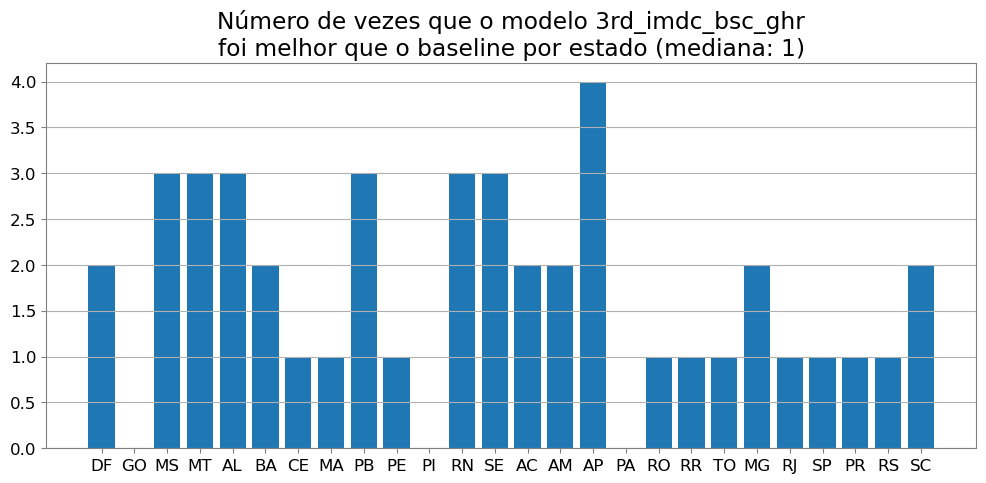

In [9]:
_, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_s_model.adm_1, df_s_model.ganhou_do_baseline)
ax.set_title(f'Número de vezes que o modelo {model}\nfoi melhor que o baseline por estado (mediana: {int(np.median(df_s_model.ganhou_do_baseline))})')
ax.grid(axis='y')

### Analisando os casos em que um modelo foi melhor que o baseline em ao menos 3 dos 4 conjuntos de validação por estado: 

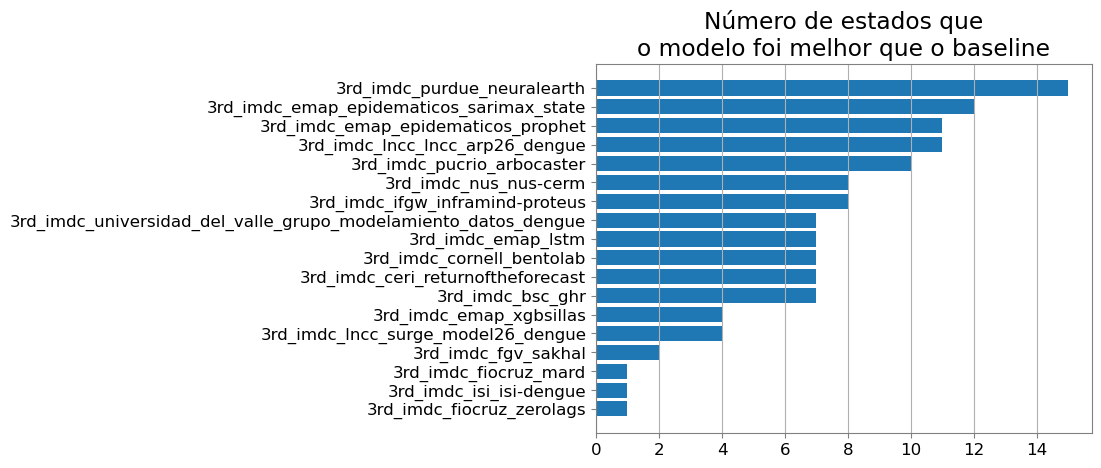

In [10]:
df_agg = modelos_selecionados_3.groupby(['model'])[['adm_1']].count()
df_agg = df_agg.sort_values(by = 'adm_1')

_, ax= plt.subplots()

ax.barh(df_agg.index, df_agg.adm_1)

ax.grid(axis = 'x')
ax.set_title('Número de estados que\no modelo foi melhor que o baseline')

plt.show()

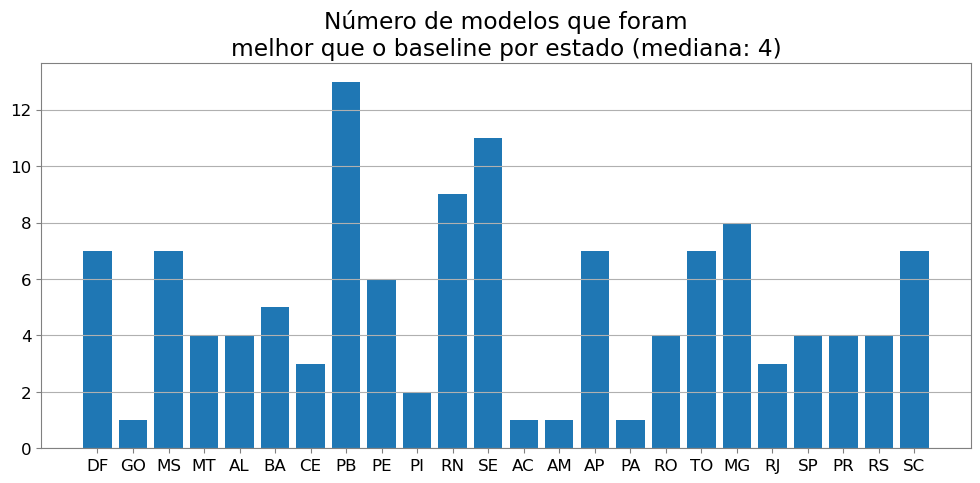

In [11]:
df_agg = modelos_selecionados_3.groupby(['adm_1'])[['model']].count().reset_index()
df_agg['adm_1'] = df_agg['adm_1'].replace(code_to_state)

# Cria a coluna de região e ordena
df_agg['regiao'] = df_agg['adm_1'].map(estado_para_regiao)
df_agg = df_agg.sort_values(by=['regiao', 'adm_1'])

# Plotagem
_, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_agg.adm_1, df_agg.model)
ax.set_title(f'Número de modelos que foram\nmelhor que o baseline por estado (mediana: {int(np.median(df_agg.model))})')
ax.grid(axis='y')

Modelos que não são melhores do que o baseline em nenhum estado: 

In [12]:
np.setdiff1d(df_preds.model.unique(), modelos_selecionados_3.model.unique())

array(['3rd_imdc_fgv_pattern-blue', '3rd_imdc_procc_bb_model',
       'DS-OKSTATE-2026'], dtype=object)